# European Dataset Experiment

## Import Libraries

In [1]:
# Import libraries

import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mafese import Data

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression  # Just for evaluating during feature selection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, roc_curve

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

## Load Data and Scaling Data for Feature Selection

In [2]:
# Load Dataset
df = pd.read_csv('creditcard.csv')

# Optional: Drop 'id' column if present
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Shuffle the data to mix Class 0 and Class 1
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare features and labels
X = df.drop('Class', axis=1)  # Features
y = df['Class']               # Labels

# x_data = X[:100001]
# y_data = y[:100001]


# Assuming X, y are your original dataset and labels
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

# Initialize mafese Data object
data = Data(X, y)

# Split the data
# (mafese automatically splits into training and testing sets)
data.split_train_test(test_size=0.3, random_state=42, inplace=True, stratify=y)  # You can adjust test_size and seed

# Scale the features
data.X_train, scaler_X = data.scale(data.X_train, scaling_methods=("standard", "minmax"))
data.X_test = scaler_X.transform(data.X_test)

# Encode the labels
data.y_train, scaler_y = data.encode_label(data.y_train)
data.y_test = scaler_y.transform(data.y_test)

# Print data shapes
print(f"Training Features Shape: {data.X_train.shape}")
print(f"Training Labels Shape: {data.y_train.shape}")
print(f"Testing Features Shape: {data.X_test.shape}")
print(f"Testing Labels Shape: {data.y_test.shape}")

Training Features Shape: (398041, 30)
Training Labels Shape: (398041,)
Testing Features Shape: (170589, 30)
Testing Labels Shape: (170589,)


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning:

X has feature names, but StandardScaler was fitted without feature names



## Exploratory Data Analysis

In [3]:
# load the dataset (read the CSV file)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
1,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
2,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
3,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
4,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [4]:
# Show the dataset information, including data types and missing values
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.176758e-15,3.384475e-16,-1.399495e-15,2.094652e-15,1.006511e-15,1.495446e-15,-5.633807e-16,1.141630e-16,-2.411994e-15,...,1.616146e-16,-3.510464e-16,2.630603e-16,4.473016e-15,5.146818e-16,1.685202e-15,-3.655912e-16,-1.227702e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

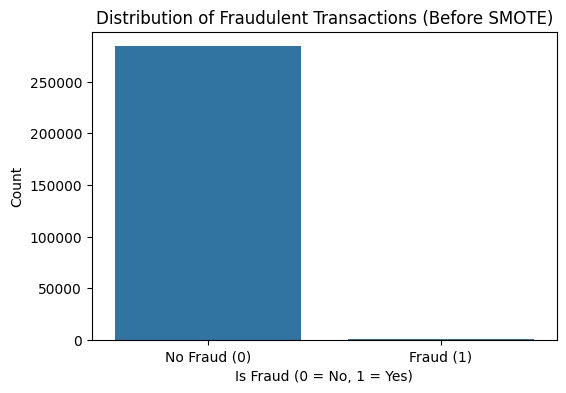

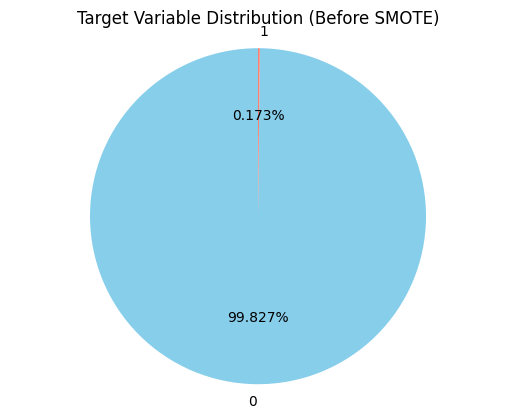

In [6]:
# Plot countplot before SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Fraudulent Transactions (Before SMOTE)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Fraud (0)', 'Fraud (1)'])
plt.show()

# Plot pie chart before SMOTE
labels = [0, 1]
sizes = df['Class'].value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%', startangle=90, colors=['skyblue', 'salmon'])
ax.set_title('Target Variable Distribution (Before SMOTE)')
ax.axis('equal')
plt.show()

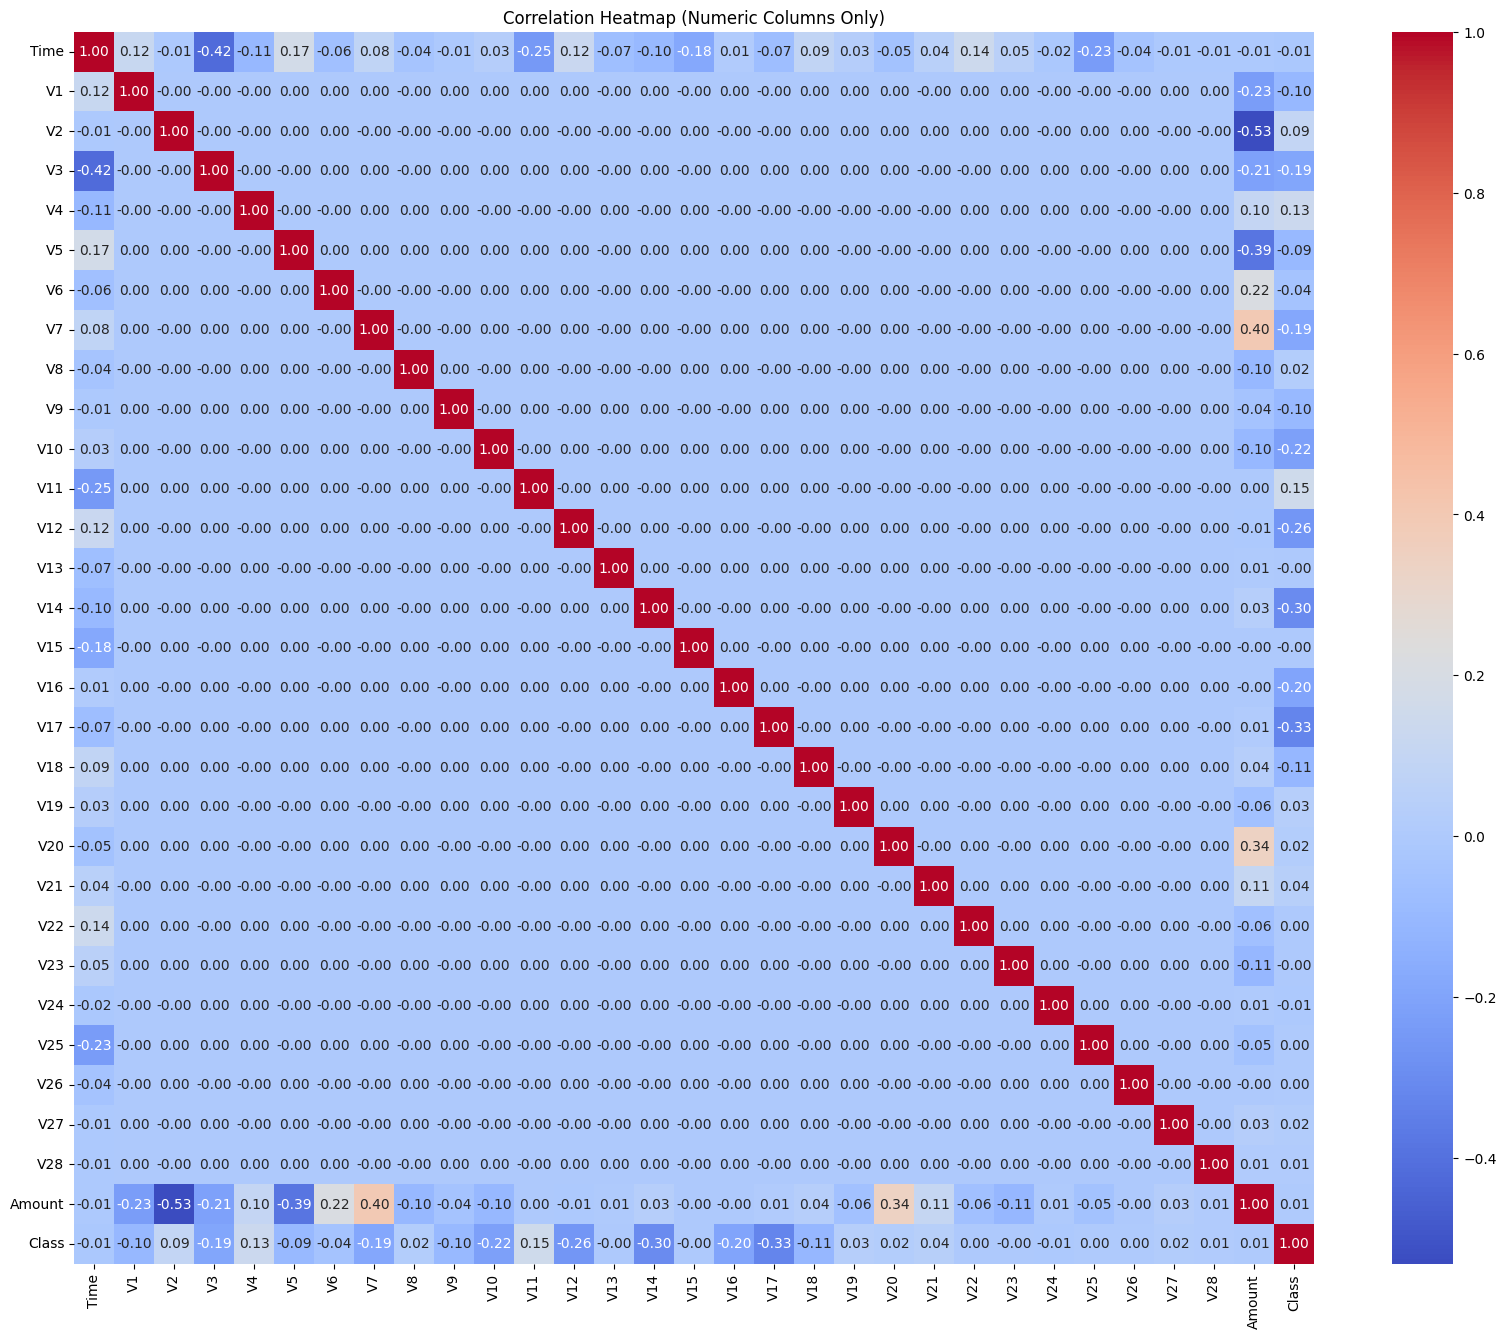

In [7]:
# Select only numeric columns for correlation analysis
numeric_data = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

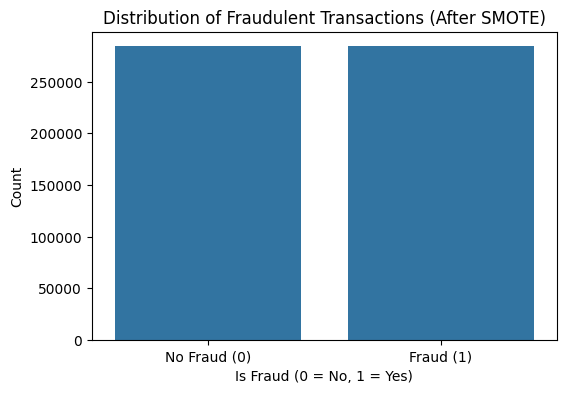

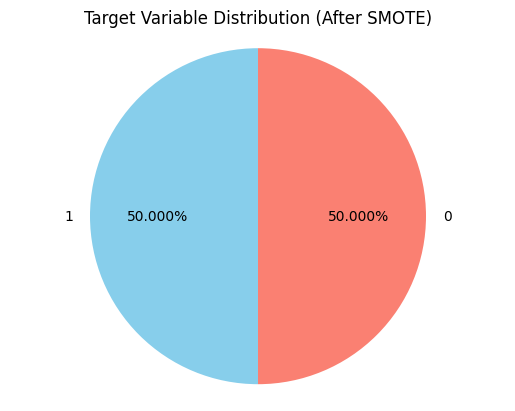

In [8]:
# Combine resampled X and y for plotting
df_smote = pd.DataFrame(X)
df_smote['Class'] = y

# Plot countplot after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df_smote)
plt.title('Distribution of Fraudulent Transactions (After SMOTE)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Fraud (0)', 'Fraud (1)'])
plt.show()

# Plot pie chart after SMOTE
labels = df_smote['Class'].unique()
sizes = df_smote['Class'].value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%', startangle=90, colors=['skyblue', 'salmon'])
ax.set_title('Target Variable Distribution (After SMOTE)')
ax.axis('equal')
plt.show()

## Initializing The BBOA Algorithm and Feature Selection Model

In [9]:
# ------------ Updated BBOA Feature Selector ---------------- #

class BBOAFeatureSelector:
    def __init__(self, n_agents=20, max_iter=30, exploration_rate=0.3, classifier=None,
                 cv_folds=5, save_dir="./bboa_results", random_state=42):
        self.n_agents = n_agents
        self.max_iter = max_iter
        self.exploration_rate = exploration_rate
        self.classifier = classifier if classifier else LogisticRegression()
        self.cv_folds = cv_folds
        self.save_dir = save_dir
        self.random_state = random_state
        np.random.seed(self.random_state)
        
        # Store fitness evolution
        self.fitness_curve = []

        # Create save directory
        os.makedirs(self.save_dir, exist_ok=True)

    def _initialize_population(self, n_features):
        return np.random.randint(0, 2, size=(self.n_agents, n_features))

    def _fitness(self, X, y, agent):
        selected_indices = np.where(agent == 1)[0]
        if len(selected_indices) == 0:
            return 0

        X_selected = X[:, selected_indices]

        clf = clone(self.classifier)
        skf = StratifiedKFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        scores = cross_val_score(clf, X_selected, y, cv=skf, scoring="accuracy")
        
        acc = np.mean(scores)
        feature_penalty = len(selected_indices) / X.shape[1]
        fitness = acc * (1 - 0.1 * feature_penalty)
        return fitness

    def fit(self, X, y):
        n_features = X.shape[1]
        self.population = self._initialize_population(n_features)
        self.best_agent = None
        self.best_fitness = -np.inf

        for iter_no in range(self.max_iter):
            start_time = time.time()  # Start timing the epoch
            fitness_values = []
            for agent in self.population:
                fitness = self._fitness(X, y, agent)
                fitness_values.append(fitness)

                if fitness > self.best_fitness:
                    self.best_fitness = fitness
                    self.best_agent = agent.copy()

            self.fitness_curve.append(self.best_fitness)

            # Update population
            new_population = []
            for agent in self.population:
                new_agent = agent.copy()

                if np.random.rand() < self.exploration_rate:
                    flip_index = np.random.randint(0, n_features)
                    new_agent[flip_index] = 1 - new_agent[flip_index]
                else:
                    move_indices = np.random.choice(n_features, size=int(0.3 * n_features), replace=False)
                    for idx in move_indices:
                        new_agent[idx] = self.best_agent[idx]

                new_population.append(new_agent)

            self.population = np.array(new_population)
            
            # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Iteration {iter_no+1}/{self.max_iter}, Best Fitness: {self.best_fitness:.4f}, Time: {elapsed_time:.2f}s")

        self._plot_fitness_curve()
        self._save_best_agent()

    def transform(self, X):
        selected_indices = np.where(self.best_agent == 1)[0]
        return X[:, selected_indices]

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def get_selected_indices(self):
        return np.where(self.best_agent == 1)[0]

    def _plot_fitness_curve(self):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.fitness_curve)+1), self.fitness_curve, marker="o")
        plt.title("BBOA Feature Selection - Fitness Evolution")
        plt.xlabel("Iteration")
        plt.ylabel("Best Fitness Score")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, "fitness_curve.png"))
        plt.show()

    def _save_best_agent(self):
        np.save(os.path.join(self.save_dir, "best_agent.npy"), self.best_agent)
        summary = {
            "selected_features_count": int(np.sum(self.best_agent)),
            "total_features": int(len(self.best_agent)),
            "best_fitness_score": float(self.best_fitness),
            "cv_folds": self.cv_folds
        }
        with open(os.path.join(self.save_dir, "summary.json"), "w") as f:
            json.dump(summary, f, indent=4)

Iteration 1/30, Best Fitness: 0.9223, Time: 58.67s
Iteration 2/30, Best Fitness: 0.9228, Time: 51.30s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Iteration 3/30, Best Fitness: 0.9274, Time: 50.70s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Iteration 4/30, Best Fitness: 0.9274, Time: 53.24s
Iteration 5/30, Best Fitness: 0.9312, Time: 47.44s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Iteration 6/30, Best Fitness: 0.9319, Time: 48.32s
Iteration 7/30, Best Fitness: 0.9336, Time: 41.35s
Iteration 8/30, Best Fitness: 0.9354, Time: 41.06s
Iteration 9/30, Best Fitness: 0.9379, Time: 35.88s
Iteration 10/30, Best Fitness: 0.9431, Time: 35.31s
Iteration 11/30, Best Fitness: 0.9448, Time: 33.92s
Iteration 12/30, Best Fitness: 0.9448, Time: 31.86s
Iteration 13/30, Best Fitness: 0.9448, Time: 28.01s
Iteration 14/30, Best Fitness: 0.9448, Time: 27.31s
Iteration 15/30, Best Fitness: 0.9449, Time: 23.47s
Iteration 16/30, Best Fitness: 0.9449, Time: 24.00s
Iteration 17/30, Best Fitness: 0.9474, Time: 26.00s
Iteration 18/30, Best Fitness: 0.9480, Time: 25.38s
Iteration 19/30, Best Fitness: 0.9480, Time: 24.80s
Iteration 20/30, Best Fitness: 0.9480, Time: 25.29s
Iteration 21/30, Best Fitness: 0.9480, Time: 23.51s
Iteration 22/30, Best Fitness: 0.9499, Time: 24.64s
Iteration 23/30, Best Fitness: 0.9499, Time: 25.24s
Iteration 24/30, Best Fitness: 0.9499, Time: 25.72s
Iteration 25/30,

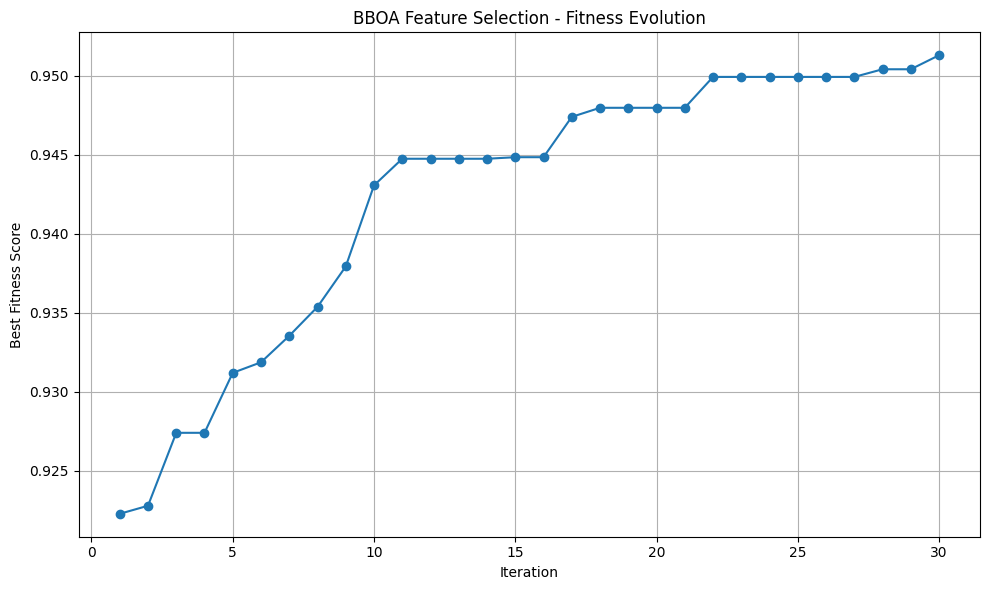

Original features: 30
Selected features: 6


In [10]:
# Initialize BBOA Feature Selector
bboa_selector = BBOAFeatureSelector(
    n_agents=20,
    max_iter=30,
    exploration_rate=0.3,
    classifier=LogisticRegression(),
    cv_folds=5,
    save_dir="./bboa_results",
    random_state=42
)

# Fit and transform your data
X_train_selected = bboa_selector.fit_transform(data.X_train, data.y_train)

# Reduce X_test as well
selected_indices = bboa_selector.get_selected_indices()
X_test_selected = data.X_test[:, selected_indices]

print(f"Original features: {data.X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

In [11]:
print(f"Original Dataset: {data.X_train.shape}")
print(f"Selected dataset: {X_test_selected.shape}")

Original Dataset: (398041, 30)
Selected dataset: (170589, 6)


In [12]:
X_train_selected.shape[1]

6

In [13]:
X_test_selected

array([[0.43695698, 0.52071235, 0.46018647, 0.33133467, 0.40467079,
        0.54995922],
       [0.24475942, 0.63226601, 0.72190537, 0.64061139, 0.55865415,
        0.72348074],
       [0.25809486, 0.58671831, 0.73289696, 0.65276745, 0.65408346,
        0.72376118],
       ...,
       [0.62232107, 0.31433459, 0.19810108, 0.20815658, 0.09316271,
        0.08262403],
       [0.17869689, 0.59043655, 0.74380224, 0.63525993, 0.61547694,
        0.71529625],
       [0.28474642, 0.61275611, 0.70351041, 0.66995145, 0.61895515,
        0.73326185]])

### Spiking Neural Network (SNN) Definition and Training ###

In [14]:
# --------- Simple SNN Model for Classification ------------- #

# -------- Surrogate Function --------
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input >= 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # surrogate gradient: d(ReLU)/dx (approximate)
        surrogate_grad = torch.sigmoid(5 * input) * (1 - torch.sigmoid(5 * input))
        return grad_input * surrogate_grad

surrogate_spike_fn = SurrogateSpike.apply

# -------- Updated SNNLayer --------
class SNNLayer(nn.Module):
    def __init__(self, in_features, out_features, threshold=1.0, decay=0.9):
        super(SNNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.threshold = threshold
        self.decay = decay
        self.mem = None

    def forward(self, x):
        if self.mem is None:
            self.mem = torch.zeros(x.size(0), self.fc.out_features, device=x.device)

        current = self.fc(x)
        self.mem = self.mem * self.decay + current
        spike = surrogate_spike_fn(self.mem - self.threshold)
        self.mem = self.mem * (1 - spike)  # reset after spike
        return spike

    def reset(self):
        self.mem = None

# -------- Updated SNNClassifier --------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, threshold=1.0):
        super(SNNClassifier, self).__init__()
        self.snn1 = SNNLayer(input_dim, hidden_dim, threshold=threshold)
        self.snn2 = SNNLayer(hidden_dim, output_dim, threshold=threshold)

    def forward(self, x, time_steps=20):
        out_spikes = torch.zeros(x.size(0), self.snn2.fc.out_features, device=x.device)
        for t in range(time_steps):
            spike1 = self.snn1(x)
            spike2 = self.snn2(spike1)
            out_spikes += spike2
        return out_spikes  # output spike counts (higher means more confident)

    def reset(self):
        self.snn1.reset()
        self.snn2.reset()

# -------- Updated SNNTrainer --------
class SNNTrainer:
    def __init__(self, model, lr=1e-3, epochs=50, batch_size=32, device=None):
        self.model = model
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.losses = []

    def fit(self, X_train, y_train):
        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.long)

        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(self.epochs):
            
            start_time = time.time()
            
            self.model.train()
            epoch_loss = 0
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                self.model.reset()
                out = self.model(xb)

                loss = criterion(out, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(loader)
            self.losses.append(avg_epoch_loss)

             # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Epoch {epoch+1}/{self.epochs}, Loss: {avg_epoch_loss:.4f}, Time: {elapsed_time:.2f}s")

    def plot_training_loss(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.losses, label="Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.legend()
        plt.grid()
        plt.show()

    def evaluate(self, X_test, y_test):
        self.model.eval()
        X_test = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(self.device)
    
        self.model.reset()
        out = self.model(X_test)  # raw logits or probabilities
        preds = torch.argmax(out, dim=1)
    
        y_true = y_test.cpu().numpy()
        y_pred = preds.cpu().numpy()
    
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")
    
        # MCC
        mcc = matthews_corrcoef(y_true, y_pred)
    
        # AUC-ROC Score (binary or one-vs-rest)
        if out.shape[1] == 2:
            probs = torch.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
            auc_roc = roc_auc_score(y_true, probs)
            
            # Plot ROC curve
            fpr, tpr, _ = roc_curve(y_true, probs)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {auc_roc:.4f}')
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            auc_roc = roc_auc_score(y_true, out.detach().cpu().numpy(), multi_class='ovr', average='weighted')
    
        # Print Metrics
        print("\nClassification Report:\n", classification_report(y_true, y_pred))
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("MCC:", mcc)
        print("AUC-ROC Score:", auc_roc)
    
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    
        return acc, precision, recall, f1, mcc, auc_roc

    def save_model(self, path="./snn_model.pth"):
        torch.save(self.model.state_dict(), path)

    def load_model(self, path="./snn_model.pth"):
        self.model.load_state_dict(torch.load(path, map_location=self.device))

Epoch 1/30, Loss: 0.0949, Time: 54.92s
Epoch 2/30, Loss: 0.0868, Time: 52.01s
Epoch 3/30, Loss: 0.0857, Time: 52.57s
Epoch 4/30, Loss: 0.0843, Time: 51.95s
Epoch 5/30, Loss: 0.0831, Time: 51.89s
Epoch 6/30, Loss: 0.0892, Time: 53.10s
Epoch 7/30, Loss: 0.0879, Time: 52.44s
Epoch 8/30, Loss: 0.0833, Time: 54.38s
Epoch 9/30, Loss: 0.0821, Time: 53.59s
Epoch 10/30, Loss: 0.0800, Time: 52.90s
Epoch 11/30, Loss: 0.0777, Time: 52.23s
Epoch 12/30, Loss: 0.0789, Time: 53.20s
Epoch 13/30, Loss: 0.0788, Time: 52.39s
Epoch 14/30, Loss: 0.0780, Time: 54.37s
Epoch 15/30, Loss: 0.0777, Time: 53.65s
Epoch 16/30, Loss: 0.0829, Time: 52.36s
Epoch 17/30, Loss: 0.0810, Time: 53.69s
Epoch 18/30, Loss: 0.0793, Time: 55.61s
Epoch 19/30, Loss: 0.0803, Time: 55.39s
Epoch 20/30, Loss: 0.0789, Time: 52.98s
Epoch 21/30, Loss: 0.0767, Time: 53.81s
Epoch 22/30, Loss: 0.0799, Time: 55.33s
Epoch 23/30, Loss: 0.0810, Time: 54.09s
Epoch 24/30, Loss: 0.0931, Time: 55.07s
Epoch 25/30, Loss: 0.0900, Time: 54.09s
Epoch 26/

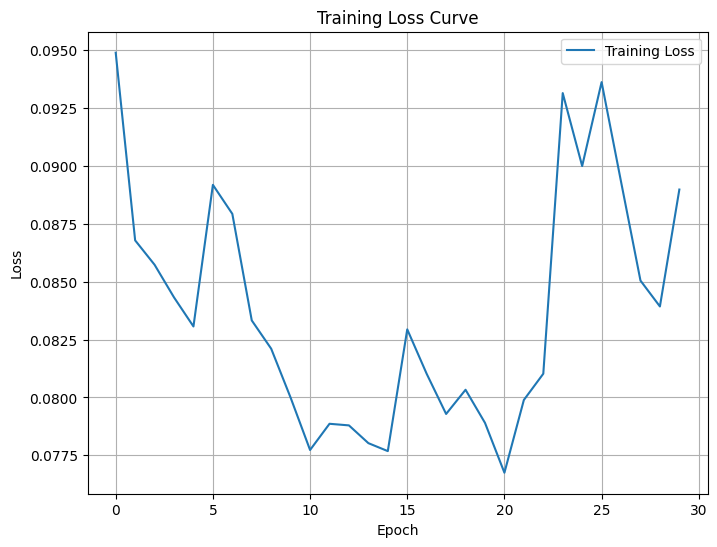

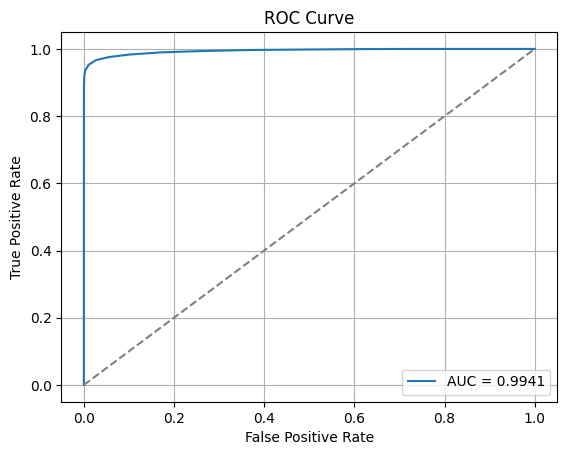


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     85295
           1       0.97      0.97      0.97     85294

    accuracy                           0.97    170589
   macro avg       0.97      0.97      0.97    170589
weighted avg       0.97      0.97      0.97    170589

Accuracy: 0.9698163422026039
Precision: 0.9698340057987396
Recall: 0.9698163422026039
F1 Score: 0.9698160579484005
MCC: 0.9396503467482991
AUC-ROC Score: 0.9941475932626356


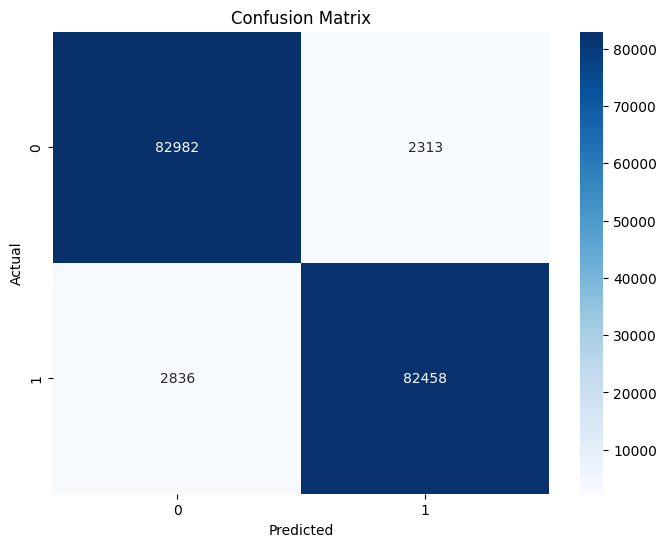

In [15]:
# Initialize
input_dim = X_train_selected.shape[1]
hidden_dim = 128
output_dim = len(np.unique(data.y_train))  # number of classes

snn_model = SNNClassifier(input_dim, hidden_dim, output_dim)

# Train
trainer = SNNTrainer(snn_model, lr=0.001, epochs=30, batch_size=32)
trainer.fit(X_train_selected, data.y_train)

# Plot Training Loss
trainer.plot_training_loss()

# Evaluate
trainer.evaluate(X_test_selected, data.y_test)

# Save Model
trainer.save_model("./bboa_selected_snn_model.pth")